# Perceptual Encoder Tests

In [1]:
import numpy as np
import torch
import torch.nn.functional as F
from torchvision.io import read_image
import matplotlib.pyplot as plt

from encoder import (
    N_SCORE_FILES,
    OUT_DIR,
    get_device,
    load_generator,
    load_model_state,
    normalize_for_resnet,
    preprocess_prediction,
)
from perceptual_encoder import (
    MODEL_PATH,
    SYNTHESIS_RESOLUTION,
    decode_w,
    build_resnet_wplus,
    synthesize_to_resolution,
    synthesis_kwargs,
    generated_to_image,
)


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/antoningranados/Documents/School/Telecom/ima/APM_4IM06_TP/project.nosync/Latent-Space-Faces/venv/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Users/antoningranados/Documents/School/Telecom/ima/APM_4IM06_TP/project.nosync/Latent-Space-Faces/venv/lib/python3.11/site-packages/traitlets/config/application.py", line 1082, in launch_instance
  

In [2]:
SEED = 32
_ = torch.manual_seed(SEED)

device = get_device()
print(device)

mps


In [3]:
G = load_generator(device)
w_avg = G.mapping.w_avg.detach().to(device)

In [4]:
resnet = build_resnet_wplus(G.num_ws, G.w_dim).to(device)
epoch = load_model_state(resnet, MODEL_PATH, device)
print(f"Loaded {MODEL_PATH} at epoch {epoch}")
_ = resnet.eval()


def to_resnet_input(imgs: torch.Tensor) -> torch.Tensor:
    """Resize to 224×224 and apply ImageNet normalization. MPS-safe (no antialias)."""
    if imgs.dim() == 3:
        imgs = imgs.unsqueeze(0)
    imgs = F.interpolate(imgs, size=(224, 224), mode="bilinear", align_corners=False)
    return normalize_for_resnet(imgs)


def predict_w_plus(imgs: torch.Tensor) -> torch.Tensor:
    """Run encoder: w_pred = w_avg + delta (pSp-style)."""
    delta = resnet(to_resnet_input(imgs)).float().view(-1, G.num_ws, G.w_dim)
    return decode_w(delta, w_avg)

Loaded /Users/antoningranados/Documents/School/Telecom/ima/APM_4IM06_TP/project.nosync/Latent-Space-Faces/models/perceptual_encoder.pt at epoch 100


In [5]:
def _to_numpy(t: torch.Tensor) -> np.ndarray:
    """Tensor → numpy without torch's C-level bridge (NumPy 2.x safe)."""
    return np.array(t.cpu().float().tolist(), dtype=np.float32)

In [6]:
N_TEST = 4
skwargs = synthesis_kwargs(device)

with torch.inference_mode():
    z = torch.randn([N_TEST, G.z_dim]).to(device)
    w = G.mapping(z, None)

    originals = ((G.synthesis(w, **skwargs) + 1) / 2).clamp(0, 1)  # [B,C,1024,1024], [0,1]

    w_pred = predict_w_plus(originals)

    reconstructions = generated_to_image(
        synthesize_to_resolution(G, w_pred, SYNTHESIS_RESOLUTION, **skwargs),
        size=SYNTHESIS_RESOLUTION,
    )  # [B,C,1024,1024], [0,1]

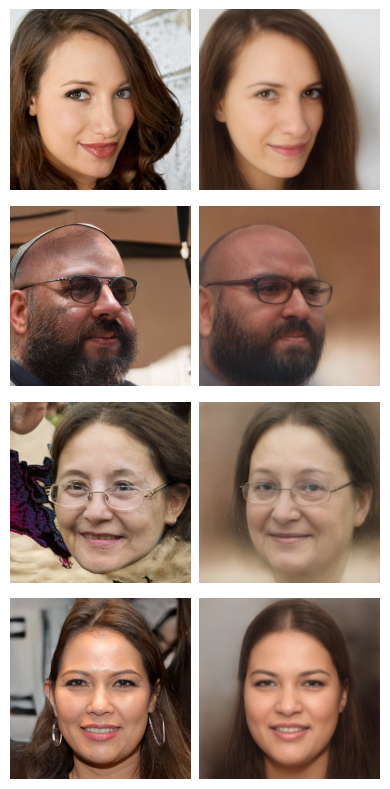

In [7]:
# plt.close("all")
# fig, axes = plt.subplots(2, N_TEST, figsize=(2*N_TEST, 4), squeeze=False)
# for i in range(N_TEST):
#     axes[0, i].imshow(_to_numpy(originals[i].permute(1, 2, 0)))
#     axes[1, i].imshow(_to_numpy(reconstructions[i].permute(1, 2, 0)))

# for ax in axes.ravel():
#     ax.set_axis_off()

# fig.tight_layout()
# _ = plt.show()
plt.close("all")
fig, axes = plt.subplots(N_TEST, 2, figsize=(4, 2*N_TEST), squeeze=False)
for i in range(N_TEST):
    axes[i, 0].imshow(_to_numpy(originals[i].permute(1, 2, 0)))
    axes[i, 1].imshow(_to_numpy(reconstructions[i].permute(1, 2, 0)))

for ax in axes.ravel():
    ax.set_axis_off()

fig.tight_layout()
_ = plt.show()

In [8]:
test_path = [
    "./dataset/whatsapp/face_01.jpeg",
    "./dataset/whatsapp/face_02.jpeg",
    "./dataset/whatsapp/face_03.jpeg",
    "./dataset/whatsapp/face_04.jpeg",
    "./dataset/whatsapp/face_05.jpeg",
    "./dataset/whatsapp/face_06.jpeg",
    "./dataset/whatsapp/face_07.jpeg",
    "./dataset/whatsapp/face_08.jpeg",
]

with torch.inference_mode():
    imgs = [read_image(path).to(dtype=torch.float32) / 255.0 for path in test_path]
    imgs_stacked = torch.stack([
        F.interpolate(img.unsqueeze(0), size=(224, 224), mode="bilinear", align_corners=False).squeeze(0)
        for img in imgs
    ]).to(device)
    w_pred = predict_w_plus(imgs_stacked)
    reconstructions = generated_to_image(
        synthesize_to_resolution(G, w_pred, SYNTHESIS_RESOLUTION, **skwargs),
        size=SYNTHESIS_RESOLUTION,
    )  # [B,C,1024,1024], [0,1]

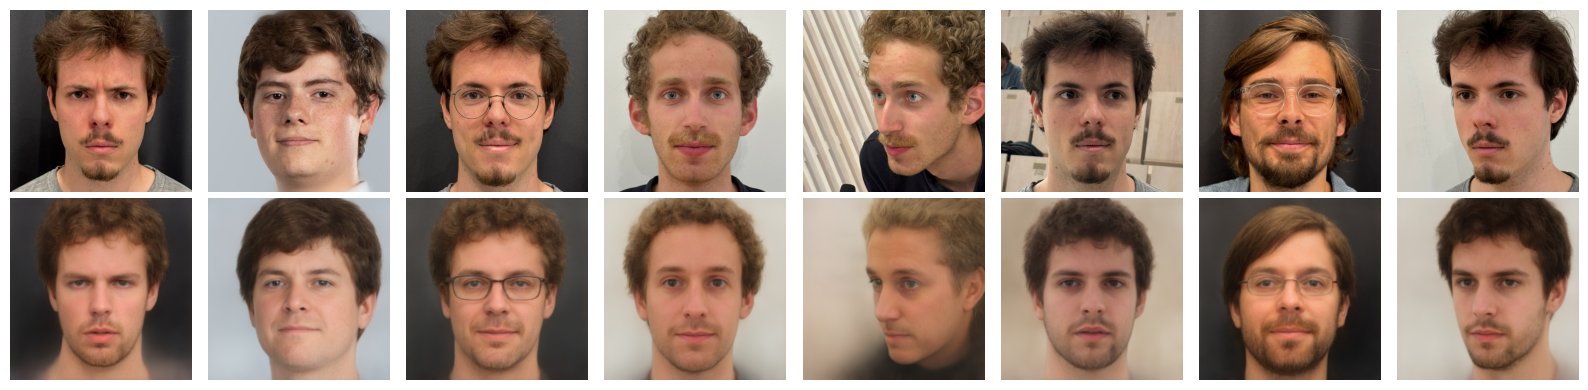

In [9]:
plt.close("all")
n = len(test_path)
fig, axes = plt.subplots(2, n, figsize=(2*n, 4), squeeze=False)
for i in range(n):
    axes[0, i].imshow(_to_numpy(imgs[i].permute(1, 2, 0)))
    axes[1, i].imshow(_to_numpy(reconstructions[i].permute(1, 2, 0)))

for ax in axes.ravel():
    ax.set_axis_off()
fig.tight_layout()
_ = plt.show()